# Ecommerce Product Category Classification

## Imports

In [20]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sentence_transformers import SentenceTransformer

import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = "../data/raw/train.csv"

print("Setup done")

Setup done


## Fast-check

In [2]:
df = pd.read_csv(DATA_PATH)[['title', 'categories']]
display(df.head())
print(df.shape)
print('Число явных дубликатов:', df.duplicated().sum())
df.info()

,title,categories
0,TUNGSTEN SOLDER PICK WITH HANDLE,"Arts, Crafts & Sewing"
1,Write Right 98167 Screen Protector for Sony T615C,Cell Phones & Accessories
2,Casio Mens DBC310-1 Databank 300 Digital Watch...,"Clothing, Shoes & Jewelry"
3,Factory-Reconditioned DEWALT DW260KR Heavy-Dut...,Tools & Home Improvement
4,Energizer 2 in 1 Light,Health & Personal Care


(46229, 2)
Число явных дубликатов: 328
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46229 entries, 0 to 46228
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       46228 non-null  object
 1   categories  46229 non-null  object
dtypes: object(2)
memory usage: 722.5+ KB


только 1 пропуск в описании запроса, но при этом, есть много(328) дубликатов

## EDA

Посмотрим на распределение классов

categories
Arts, Crafts & Sewing     2225
Beauty                    2202
Grocery & Gourmet Food    2201
Sports & Outdoors         2201
Automotive                2200
Name: count, dtype: int64

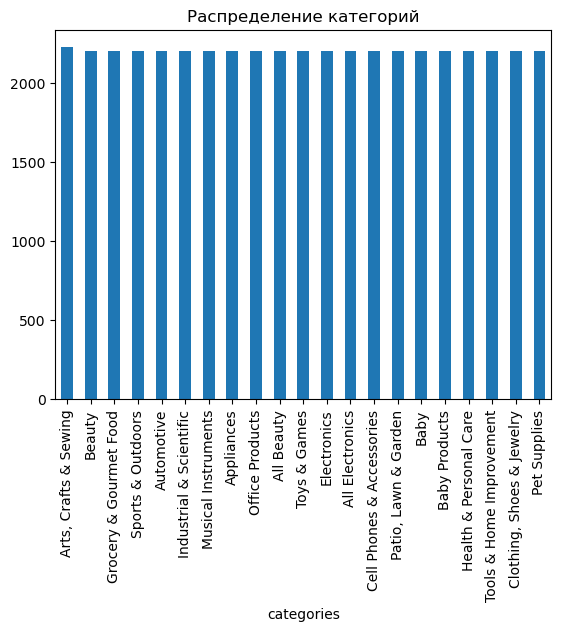

In [3]:
class_dist = df['categories'].value_counts()
display(class_dist.head())

class_dist.plot(kind='bar')
plt.title('Распределение категорий')
plt.show()

датасет практически идеально сбалансирован

Взглянем на распределение длин текстов

count    46229.000000
mean        54.535227
std         29.925365
min          0.000000
25%         36.000000
50%         49.000000
75%         65.000000
max        549.000000
Name: text_length, dtype: float64

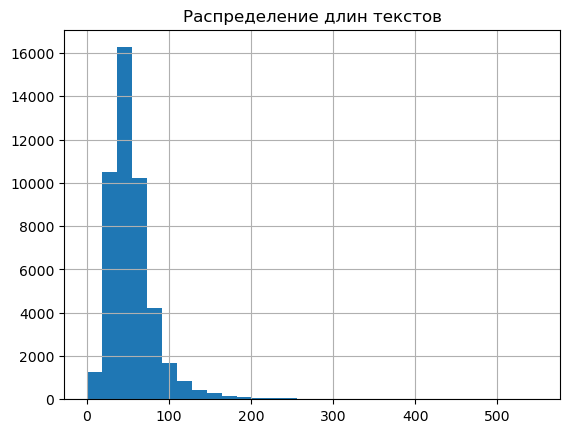

In [4]:
df['text_length'] = df['title'].fillna('').apply(len)
display(df['text_length'].describe())

df['text_length'].hist(bins=30)
plt.title('Распределение длин текстов')
plt.show()

Посмотрим на несколько сэмплов текста

In [5]:
for text in df['title'].head(5):
    print(text)
    print('-' * 50)

TUNGSTEN SOLDER PICK WITH HANDLE
--------------------------------------------------
Write Right 98167 Screen Protector for Sony T615C
--------------------------------------------------
Casio Mens DBC310-1 Databank 300 Digital Watch (Discontinued by Manufacturer)
--------------------------------------------------
Factory-Reconditioned DEWALT DW260KR Heavy-Duty 6.2 Amp Screwdriver Kit
--------------------------------------------------
Energizer 2 in 1 Light
--------------------------------------------------


Запросы выглядят осмысленно и содеджат ключевые слова

Посмотрим, есть ли пустые тексты

In [6]:
df[df['title'].str.strip() == '']

,title,categories,text_length


### Итог EDA

- Датасет содержит ~46k объектов и 21 категорий
- Классы распределены равномерно → сильного дисбаланса нет
- Названия товаров (title) короткие и информативные
- Большинство title имеют длину до ~100 символов

## Data preparation

Удаляем дубликаты и один NaN объект

In [7]:
df = df.drop_duplicates(subset=['title', 'categories'])
df = df.dropna(subset=['title'])

Проверим датасет

In [8]:
print(df.shape)
print(df.isna().sum())
print(df.duplicated().sum())

(45900, 3)
title          0
categories     0
text_length    0
dtype: int64
0


### Data split

In [9]:
X = df["title"]
y = df["categories"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (36720,)
Test size: (9180,)


## Model Experiments

### TF-IDF

Создаём experiment для сравнения моделей в рамках задачи
классификация категорий товаров по title.

In [10]:
import os
import mlflow
print("CWD:", os.getcwd())
print("Tracking URI:", mlflow.get_tracking_uri())

CWD: c:\Users\79104\Data Science\Data-Science-\SoloProjects\ml-category-service\notebooks
Tracking URI: sqlite:///C:/Users/79104/Data%20Science/Data-Science-/SoloProjects/ml-category-service/notebooks/mlflow.db


In [11]:
MLFLOW_EXPERIMENT_NAME = "retail-title-classification"
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

c:\Users\79104\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:c:/Users/79104/Data '
 'Science/Data-Science-/SoloProjects/ml-category-service/notebooks/../mlruns/270068449986130060'), creation_time=1775323794940, experiment_id='270068449986130060', last_update_time=1775323794940, lifecycle_stage='active', name='retail-title-classification', tags={}, workspace='default'>

#### TF-IDF + LogRegression

Создадим пайплайн preprocessing и модели

In [12]:
tfidf_logreg_pipeline = Pipeline(
    steps=[
        (
            'vectorizer',
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                max_features=20000
            ),
        ),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

tfidf_logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Обучим baseline модель и будем логировать её через mlflow

In [13]:
with mlflow.start_run(run_name='tfidf_logreg_baseline'):
    tfidf_logreg_pipeline.fit(X_train, y_train)

    t0 = time.perf_counter()
    y_pred = tfidf_logreg_pipeline.predict(X_test)
    pred_time_sec = time.perf_counter() - t0

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    mlflow.log_param("model_type", "tfidf_logreg")
    mlflow.log_param("text_column", "title")
    mlflow.log_param("target_column", "categories")
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("max_features", 30000)
    mlflow.log_param("lowercase", True)
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("pred_time_sec", pred_time_sec)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("weighted_f1", weighted_f1)

    mlflow.sklearn.log_model(
        sk_model=tfidf_logreg_pipeline,
        artifact_path='model'
    )

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/06 15:51:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 15:51:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [14]:
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

               All Beauty       0.66      0.60      0.63       439
          All Electronics       0.64      0.58      0.61       439
               Appliances       0.91      0.88      0.90       439
    Arts, Crafts & Sewing       0.78      0.82      0.80       444
               Automotive       0.84      0.83      0.84       438
                     Baby       0.75      0.80      0.77       436
            Baby Products       0.76      0.64      0.70       429
                   Beauty       0.67      0.71      0.69       440
Cell Phones & Accessories       0.86      0.92      0.89       438
Clothing, Shoes & Jewelry       0.78      0.83      0.80       427
              Electronics       0.85      0.82      0.84       439
   Grocery & Gourmet Food       0.84      0.88      0.86       439
   Health & Personal Care       0.71      0.69      0.70       438
  Industrial & Scientific       0.73      0.73      0.73     

Baseline TF-IDF + LogisticRegression показал сильный результат: accuracy и macro F1 составили 0.79.

Поскольку macro F1 и weighted F1 практически совпадают, можно сделать вывод, что модель работает стабильно по всем категориям, без сильного перекоса в сторону отдельных классов. Это согласуется с тем, что датасет сбалансирован.

Лучше всего модель распознаёт категории с более специфичной лексикой, например Musical Instruments, Appliances и Cell Phones & Accessories. Слабее качество у более пересекающихся категорий, таких как All Beauty, Beauty и All Electronics.

#### MultinomialNB

In [15]:
tfidf_nb_pipeline = Pipeline(
    steps=[
        (
            "vectorizer",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                max_features=30000,
            ),
        ),
        (
            "classifier",
            MultinomialNB(alpha=1.0),
        ),
    ]
)

tfidf_nb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [16]:
with mlflow.start_run(run_name="tfidf_multinomialnb_baseline"):
    tfidf_nb_pipeline.fit(X_train, y_train)

    t0 = time.perf_counter()
    y_pred = tfidf_nb_pipeline.predict(X_test)
    pred_time_sec = time.perf_counter() - t0

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    mlflow.log_param("model_type", "tfidf_multinomialnb")
    mlflow.log_param("text_column", "title")
    mlflow.log_param("target_column", "categories")
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("max_features", 30000)
    mlflow.log_param("lowercase", True)
    mlflow.log_param("alpha", 1.0)
    
    mlflow.log_metric("pred_time_sec", pred_time_sec)
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("weighted_f1", weighted_f1)

    mlflow.sklearn.log_model(
        sk_model=tfidf_nb_pipeline,
        artifact_path="model",
    )

print(classification_report(y_test, y_pred))

2026/04/06 15:52:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 15:52:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


                           precision    recall  f1-score   support

               All Beauty       0.71      0.58      0.64       439
          All Electronics       0.66      0.46      0.54       439
               Appliances       0.86      0.91      0.88       439
    Arts, Crafts & Sewing       0.76      0.82      0.79       444
               Automotive       0.83      0.80      0.82       438
                     Baby       0.72      0.83      0.77       436
            Baby Products       0.74      0.61      0.67       429
                   Beauty       0.59      0.75      0.66       440
Cell Phones & Accessories       0.76      0.94      0.84       438
Clothing, Shoes & Jewelry       0.81      0.83      0.82       427
              Electronics       0.79      0.83      0.81       439
   Grocery & Gourmet Food       0.86      0.89      0.87       439
   Health & Personal Care       0.73      0.66      0.69       438
  Industrial & Scientific       0.73      0.72      0.72     

Модель TF-IDF + MultinomialNB показала результат немного хуже, чем LogisticRegression (accuracy ~0.78 против ~0.79).

Особенно заметно снижение качества на категориях с пересекающейся лексикой, таких как All Electronics и Beauty. Это связано с тем, что MultinomialNB предполагает независимость признаков и хуже справляется с похожими классами.

MultinomialNB показывает более низкое время инференса, однако LogisticRegression даёт немного более высокое качество и более стабильные результаты по классам.

С учётом того, что разница в latency невелика, LogisticRegression выглядит более предпочтительным кандидатом для production-like сервиса.


### Embeddings

Посмотрим, даёт ли семантическое представление текста прирост качества

In [21]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/1148 [00:00<?, ?it/s]

Batches:   0%|          | 0/287 [00:00<?, ?it/s]

In [22]:
embedding_clf = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1
)

In [25]:
with mlflow.start_run(run_name='embedding_logreg'):
    embedding_clf.fit(X_train_embeddings, y_train)

    t0 = time.perf_counter()
    y_pred = embedding_clf.predict(X_test_embeddings)
    pred_time_sec = time.perf_counter() - t0

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    mlflow.log_param("model_type", "embeddings_logreg")
    mlflow.log_param("embedding_model", "all-MiniLM-L6-v2")

    mlflow.log_metric('pred_time_sec', pred_time_sec)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("macro_f1", macro_f1)
    mlflow.log_metric("weighted_f1", weighted_f1)

print(classification_report(y_test, y_pred))

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


                           precision    recall  f1-score   support

               All Beauty       0.56      0.49      0.52       439
          All Electronics       0.56      0.49      0.52       439
               Appliances       0.86      0.84      0.85       439
    Arts, Crafts & Sewing       0.63      0.66      0.64       444
               Automotive       0.65      0.70      0.67       438
                     Baby       0.61      0.59      0.60       436
            Baby Products       0.65      0.51      0.58       429
                   Beauty       0.58      0.60      0.59       440
Cell Phones & Accessories       0.78      0.86      0.82       438
Clothing, Shoes & Jewelry       0.67      0.71      0.69       427
              Electronics       0.77      0.72      0.74       439
   Grocery & Gourmet Food       0.76      0.89      0.82       439
   Health & Personal Care       0.58      0.58      0.58       438
  Industrial & Scientific       0.52      0.50      0.51     

Модель на основе embeddings показала значительно более низкое качество (accuracy ~0.67) по сравнению с TF-IDF подходами (~0.78–0.79).

Это объясняется тем, что задача классификации product titles является keyword-driven: категории напрямую определяются наличием конкретных слов. TF-IDF эффективно захватывает такие признаки, тогда как embeddings сглаживают различия между текстами.

## Выбор модели 

По итогам экспериментов в качестве финальной модели выбрана связка **TF-IDF + LogisticRegression**.

Причины выбора:

- лучший результат по качеству среди протестированных подходов
- поддержка `predict_proba()`, необходимая для inference API
- простая сериализация и загрузка
- низкая сложность деплоя
- хорошее соотношение качества и скорости

Модель MultinomialNB показала более низкое качество, хотя и работала немного быстрее.  
Embedding-based подход показал заметно худший результат, что подтверждает, что данная задача в первую очередь определяется ключевыми словами, а не сложной семантикой.

Таким образом, TF-IDF + LogisticRegression является наиболее подходящим решением для production-like demo сервиса автокатегоризации товаров по title.

In [ ]:
x

## 5. Model Comparison with MLflow

Несмотря на то, что baseline модель TF-IDF + Logistic Regression уже показала очень высокое качество, дальнейшее сравнение моделей остаётся полезным как часть MLOps-процесса.

для всех запусков фиксируется единая схема логирования в MLflow.

#### Logged parameters
- `model_family` — семейство модели (tfidf, embeddings, transformer)
- `vectorizer_type` — тип векторизации
- `classifier_type` — тип классификатора
- `max_features` — ограничение словаря TF-IDF
- `ngram_range` — используемый диапазон n-грамм
- `embedding_model_name` — название embedding-модели
- `test_size` — доля тестовой выборки

#### Logged metrics
- `accuracy`
- `f1_macro`
- `precision_macro`
- `recall_macro`

#### Logged artifacts
- classification report
- confusion matrix
- обученная модель или pipeline
- дополнительные вспомогательные файлы эксперимента

In [17]:
# принимает векторайзер, классификатор и параметры логирования
# для повторения экспериментов
def run_sklearn_experiment(
        run_name,
        vectorizer,
        classifier,
        X_train,
        X_test, 
        y_train,
        y_test,
        params_to_log
):
    fit_transform_start = time.perf_counter()
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    vectorization_time_sec = time.perf_counter() - fit_transform_start

    train_start = time.perf_counter()
    classifier.fit(X_train_vec, y_train)
    train_time_sec = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = classifier.predict(X_test_vec)
    infer_time_sec = time.perf_counter() - infer_start

    avg_infer_ms_per_sample = (infer_time_sec / len(X_test)) * 1000

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    with mlflow.start_run(run_name=run_name):
        for key, value in params_to_log.items():
            mlflow.log_param(key, value)
        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("precision_macro", precision)
        mlflow.log_metric("recall_macro", recall)
        mlflow.log_metric("vectorization_time_sec", vectorization_time_sec)
        mlflow.log_metric("train_time_sec", train_time_sec)
        mlflow.log_metric("infer_time_sec_on_test", infer_time_sec)
        mlflow.log_metric("avg_infer_ms_per_sample", avg_infer_ms_per_sample)

        if hasattr(vectorizer, 'vocabulary_'):
            mlflow.log_metric('vocab_size', len(vectorizer.vocabulary_))

        report_path = f"artifacts/{run_name}_classification_report.json"
        with open(report_path, 'w', encoding='utf-8') as f:
            json.dump(report_dict, f, ensure_ascii=False, indent=2)
        
        mlflow.log_artifact(report_path)

    return {
        "run_name": run_name,
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
        "vectorization_time_sec": vectorization_time_sec,
        "train_time_sec": train_time_sec,
        "infer_time_sec_on_test": infer_time_sec,
        "avg_infer_ms_per_sample": avg_infer_ms_per_sample,
        "vectorizer": vectorizer,
        "classifier": classifier,
    }

In [18]:
baseline_result = run_sklearn_experiment(
    run_name="tfidf_logreg_baseline",
    vectorizer=TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english",
    ),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "tfidf",
        "vectorizer_type": "tfidf",
        "classifier_type": "logistic_regression",
        "max_features": 20000,
        "ngram_range": "(1, 2)",
        "stop_words": "english",
        "test_size": 0.2,
    },
)

baseline_result

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


NameError: name 'precision_score' is not defined

Проверим, можем ли сделать модель проще и быстрее, не потеряв сильно в качестве

In [ ]:
light_result = run_sklearn_experiment(
    run_name="tfidf_logreg_light",
    vectorizer=TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 1),
        stop_words="english",
    ),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "tfidf",
        "vectorizer_type": "tfidf",
        "classifier_type": "logistic_regression",
        "max_features": 10000,
        "ngram_range": "(1, 1)",
        "stop_words": "english",
        "test_size": 0.2,
    },
)

light_result

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'run_name': 'tfidf_logreg_light',
 'accuracy': 0.9672424061941632,
 'f1_macro': 0.9675776073630966,
 'precision_macro': 0.9693679299592391,
 'recall_macro': 0.9658990344439847,
 'vectorization_time_sec': 2.7168335000001207,
 'train_time_sec': 1.4299275999997008,
 'infer_time_sec_on_test': 0.002841500000158703,
 'avg_infer_ms_per_sample': 0.00028206273577116375,
 'vectorizer': TfidfVectorizer(max_features=10000, stop_words='english'),
 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

Light-конфигурация показала сопоставимое качество при более лёгком признаковом пространстве и, вероятно, более дешёвом pipeline

Посмотрим, помогут ли эмбеддинги улучшить качество модели

In [ ]:
def run_embedding_experiment(
    run_name,
    embedder,
    classifier,
    X_train,
    X_test,
    y_train,
    y_test,
    params_to_log,
    batch_size=64,
):
    embed_start = time.perf_counter()
    X_train_emb = embedder.encode(
        X_train.tolist(),
        show_progress_bar=True,
        batch_size=batch_size,
    )
    X_test_emb = embedder.encode(
        X_test.tolist(),
        show_progress_bar=True,
        batch_size=batch_size,
    )
    embedding_time_sec = time.perf_counter() - embed_start

    train_start = time.perf_counter()
    classifier.fit(X_train_emb, y_train)
    train_time_sec = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = classifier.predict(X_test_emb)
    infer_time_sec = time.perf_counter() - infer_start
    avg_infer_ms_per_sample = (infer_time_sec / len(X_test_emb)) * 1000

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    with mlflow.start_run(run_name=run_name):
        for key, value in params_to_log.items():
            mlflow.log_param(key, value)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("precision_macro", precision)
        mlflow.log_metric("recall_macro", recall)
        mlflow.log_metric("embedding_time_sec", embedding_time_sec)
        mlflow.log_metric("train_time_sec", train_time_sec)
        mlflow.log_metric("infer_time_sec_on_test", infer_time_sec)
        mlflow.log_metric("avg_infer_ms_per_sample", avg_infer_ms_per_sample)
        mlflow.log_metric("embedding_dim", X_train_emb.shape[1])

        report_path = f"artifacts/{run_name}_classification_report.json"
        with open(report_path, "w", encoding="utf-8") as f:
            json.dump(report_dict, f, ensure_ascii=False, indent=2)

        mlflow.log_artifact(report_path)

    return {
        "run_name": run_name,
        "accuracy": acc,
        "f1_macro": f1,
        "precision_macro": precision,
        "recall_macro": recall,
        "embedding_time_sec": embedding_time_sec,
        "train_time_sec": train_time_sec,
        "infer_time_sec_on_test": infer_time_sec,
        "avg_infer_ms_per_sample": avg_infer_ms_per_sample,
        "embedder": embedder,
        "classifier": classifier,
    }

In [ ]:
embedding_result = run_embedding_experiment(
    run_name="embeddings_minilm_logreg",
    embedder=SentenceTransformer("all-MiniLM-L6-v2"),
    classifier=LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
    ),
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    params_to_log={
        "model_family": "embeddings",
        "embedding_model_name": "all-MiniLM-L6-v2",
        "classifier_type": "logistic_regression",
        "test_size": 0.2,
        "batch_size": 64,
    },
    batch_size=64,
)

embedding_result

Batches:   0%|          | 0/630 [00:00<?, ?it/s]

Batches:   0%|          | 0/158 [00:00<?, ?it/s]

c:\Users\79104\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'run_name': 'embeddings_minilm_logreg',
 'accuracy': 0.9470915227317848,
 'f1_macro': 0.9480259086118172,
 'precision_macro': 0.9490600639186677,
 'recall_macro': 0.9471474551714207,
 'embedding_time_sec': 40.49188940000022,
 'train_time_sec': 0.7460759000000508,
 'infer_time_sec_on_test': 0.011848300000110612,
 'avg_infer_ms_per_sample': 0.0011761266627070292,
 'embedder': SentenceTransformer(
   (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
   (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
   (2): Normalize()
 ),
 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

Embedding-based подход показал более низкое качество по сравнению с TF-IDF baseline (~2% разницы в F1_macro).

Это можно объяснить спецификой датасета: тексты представляют собой короткие keyword-style описания товаров, где наличие конкретных слов напрямую связано с категорией.

Несмотря на это, также посмотрим, как справится с задачей BERT-модель

In [ ]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_labels = len(label_encoder.classes_)

train_df = pd.DataFrame({
    "text": X_train.tolist(),
    "label": y_train_enc,
})

test_df = pd.DataFrame({
    "text": X_test.tolist(),
    "label": y_test_enc,
})

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [ ]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=256
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro": recall_score(labels, preds, average="macro"),
    }

In [ ]:
train_dataset_tok = train_dataset.map(tokenize_function, batched=True)
test_dataset_tok = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/40295 [00:00<?, ? examples/s]

Map:   0%|          | 0/10074 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir='distilbert_results',
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    report_to='none'
)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_tok,
    eval_dataset=test_dataset_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)
train_start = time.perf_counter()

with mlflow.start_run(run_name="distilbert_classifier"):
    mlflow.log_param("model_family", "transformer")
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("max_length", 256)
    mlflow.log_param("num_train_epochs", 1)
    mlflow.log_param("per_device_train_batch_size", 16)
    mlflow.log_param("per_device_eval_batch_size", 16)
    mlflow.log_param("weight_decay", 0.01)
    mlflow.log_param("test_size", 0.2)

    train_start = time.perf_counter()
    trainer.train()
    train_time_sec = time.perf_counter() - train_start

    pred_start = time.perf_counter()
    preds_output = trainer.predict(test_dataset_tok)
    pred_time_sec = time.perf_counter() - pred_start

    y_pred = preds_output.predictions.argmax(axis=1)
    y_true = preds_output.label_ids

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)
    mlflow.log_metric("precision_macro", precision)
    mlflow.log_metric("recall_macro", recall)

    mlflow.log_metric("train_time_sec", train_time_sec)
    mlflow.log_metric("predict_time_sec", pred_time_sec)

    

distilbert_eval

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\79104\AppData\Local\Temp\ipykernel_9372\484561385.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.177300,0.118695,0.972702,0.973115,0.974214,0.972064
2,0.067800,0.099879,0.980246,0.980375,0.980863,0.979917


{'eval_loss': 0.11651966720819473,
 'eval_accuracy': 0.973198332340679,
 'eval_f1_macro': 0.97356313421151,
 'eval_precision_macro': 0.9742469085464001,
 'eval_recall_macro': 0.9729106030593926,
 'eval_runtime': 33.839,
 'eval_samples_per_second': 297.704,
 'eval_steps_per_second': 18.618,
 'epoch': 1.0}

Качество предсказаний BERT, модели немногим лучше остальных моделей, однако стоит иметь в виду, что сама по себе модель достаточно тяжёлая

## Model Selection



По итогам сравнения нескольких подходов в качестве финальной модели для inference API была выбрана конфигурация **TF-IDF + Logistic Regression (light)**, так как эта модель обеспечивает высокий уровень качества при минимальной сложности deployment pipeline.

- 'vectorizer': TfidfVectorizer(max_features=10000, stop_words='english'),
- 'classifier': LogisticRegression(max_iter=1000, n_jobs=-1)}

## Conclusions

В рамках ноутбука был построен и проанализирован NLP pipeline для задачи автокатегоризации товаров по текстовому описанию.

### Что было сделано

- проведён базовый анализ датасета
- исследованы распределение классов и свойства текстов
- обучен baseline на основе TF-IDF + Logistic Regression
- проведено сравнение нескольких подходов через MLflow:
  - TF-IDF family
  - sentence embeddings + classifier
  - DistilBERT
- выполнен выбор финальной модели с учётом не только качества, но и production trade-offs

### Главная мысль

Несмотря на наличие более сложных моделей, наиболее практичным решением для данного проекта оказался **TF-IDF + Logistic Regression**.

Это связано с тем, что:
- датасет содержит короткие keyword-oriented описания товаров
- простая линейная модель уже показывает очень высокое качество
- усложнение pipeline не даёт достаточной практической выгоды для inference-сервиса

Следующий этап проекта — вынести финальное обучение в `training/train.py`, сохранить модель в `models/` и использовать её в FastAPI inference API.